In [1]:
from pathlib import Path

BASE_DIR = Path("e1_artifacts")
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"

for folder in [BASE_DIR, LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Созданы папки:")
for folder in [LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR]:
    print(folder.resolve())

Созданы папки:
/content/e1_artifacts/logs
/content/e1_artifacts/tables
/content/e1_artifacts/figures
/content/e1_artifacts/reports


In [2]:
import pandas as pd

TRAIN_PATH = "train_final.csv"
TEST_PATH = "test_final.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

train_df shape: (7957, 3)
test_df shape: (2211, 3)


,text,label,id
0,@YELLEZ @WylsacomRed Почему бы просто не купит...,neutral,1215652526319722501
1,"посмотрите кто-нибудь ""импровизацию""..\r\nя хо...",positive,1341141182093668352
2,@robodeacon зашел сфоткаться с кастом тени и к...,neutral,1234077503993581569
3,Моя оформа: /меняется на чёрно-белую/\r\n\r\nМ...,neutral,1326075120465702912
4,сижу в такси рядом ползает паук няшка,positive,1276191130535821315


,text,label,id
0,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,1218052288964632576
1,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive,1212859589592539136
2,@daria_karapet * терияки бойз начинает играть*,neutral,1321540138334302209
3,(пушка на Караульной горе больше не стреляет Б...,negative,1342696727808274432
4,@Iori_loves_U Как мило /смутилась/ спасибо 🥰🌸,positive,1317052132382679041


In [3]:
X_train = train_df["text"].copy()
y_train = train_df["label"].copy()

X_test = test_df["text"].copy()
y_test = test_df["label"].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7957,)
y_train: (7957,)
X_test: (2211,)
y_test: (2211,)


In [4]:
SEED = 42

E1_CONFIG = {
    "experiment": "E1 classical model expansion",
    "dataset": "RuSentiTweet",
    "train_file": TRAIN_PATH,
    "test_file": TEST_PATH,
    "seed": SEED,
    "main_vectorizer": {
        "type": "TfidfVectorizer",
        "lowercase": True,
        "analyzer": "word",
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95
    },
    "bernoulli_vectorizer": {
        "type": "CountVectorizer",
        "binary": True,
        "lowercase": True,
        "analyzer": "word",
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95
    }
}

import json
with open(LOG_DIR / "e1_config.json", "w", encoding="utf-8") as f:
    json.dump(E1_CONFIG, f, ensure_ascii=False, indent=4)

print("Saved:", LOG_DIR / "e1_config.json")

Saved: e1_artifacts/logs/e1_config.json


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (7957, 8037)
X_test_tfidf shape: (2211, 8037)


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

binary_vectorizer = CountVectorizer(
    lowercase=True,
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    binary=True
)

X_train_binary = binary_vectorizer.fit_transform(X_train)
X_test_binary = binary_vectorizer.transform(X_test)

print("X_train_binary shape:", X_train_binary.shape)
print("X_test_binary shape:", X_test_binary.shape)

X_train_binary shape: (7957, 8037)
X_test_binary shape: (2211, 8037)


In [7]:
e1_results = []

In [8]:
import time
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [9]:
def evaluate_model(model, model_name, representation_name, X_train_mat, y_train, X_test_mat, y_test, report_filename):
    start_time = time.time()
    model.fit(X_train_mat, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test_mat)

    acc = accuracy_score(y_test, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )
    f1_macro = f1_score(y_test, y_pred, average="macro")

    report = classification_report(y_test, y_pred, digits=4)

    with open(REPORT_DIR / report_filename, "w", encoding="utf-8") as f:
        f.write(report)

    result = {
        "model": model_name,
        "representation": representation_name,
        "accuracy": round(acc, 4),
        "precision_weighted": round(precision_w, 4),
        "recall_weighted": round(recall_w, 4),
        "weighted_f1": round(f1_w, 4),
        "macro_f1": round(f1_macro, 4),
        "train_time_sec": round(train_time, 4),
        "seed": SEED
    }

    return result, y_pred, report

In [10]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")

dummy_result, y_pred_dummy, report_dummy = evaluate_model(
    model=dummy_model,
    model_name="DummyClassifier",
    representation_name="TF-IDF word (1,2)",
    X_train_mat=X_train_tfidf,
    y_train=y_train,
    X_test_mat=X_test_tfidf,
    y_test=y_test,
    report_filename="classification_report_dummy.txt"
)

e1_results.append(dummy_result)

print(dummy_result)
print(report_dummy)

{'model': 'DummyClassifier', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.483, 'precision_weighted': 0.2333, 'recall_weighted': 0.483, 'weighted_f1': 0.3147, 'macro_f1': 0.2171, 'train_time_sec': 0.014, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000       660
     neutral     0.4830    1.0000    0.6514      1068
    positive     0.0000    0.0000    0.0000       483

    accuracy                         0.4830      2211
   macro avg     0.1610    0.3333    0.2171      2211
weighted avg     0.2333    0.4830    0.3147      2211



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
from sklearn.naive_bayes import MultinomialNB

mnb_model = MultinomialNB()

mnb_result, y_pred_mnb, report_mnb = evaluate_model(
    model=mnb_model,
    model_name="Multinomial Naive Bayes",
    representation_name="TF-IDF word (1,2)",
    X_train_mat=X_train_tfidf,
    y_train=y_train,
    X_test_mat=X_test_tfidf,
    y_test=y_test,
    report_filename="classification_report_mnb.txt"
)

e1_results.append(mnb_result)

print(mnb_result)
print(report_mnb)

{'model': 'Multinomial Naive Bayes', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.5929, 'precision_weighted': 0.6423, 'recall_weighted': 0.5929, 'weighted_f1': 0.5482, 'macro_f1': 0.4999, 'train_time_sec': 0.0312, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6338    0.3409    0.4433       660
     neutral     0.5668    0.9139    0.6996      1068
    positive     0.8209    0.2277    0.3566       483

    accuracy                         0.5929      2211
   macro avg     0.6738    0.4942    0.4999      2211
weighted avg     0.6423    0.5929    0.5482      2211



In [12]:
from sklearn.naive_bayes import BernoulliNB

bnb_model = BernoulliNB()

bnb_result, y_pred_bnb, report_bnb = evaluate_model(
    model=bnb_model,
    model_name="Bernoulli Naive Bayes",
    representation_name="Binary Count word (1,2)",
    X_train_mat=X_train_binary,
    y_train=y_train,
    X_test_mat=X_test_binary,
    y_test=y_test,
    report_filename="classification_report_bnb.txt"
)

e1_results.append(bnb_result)

print(bnb_result)
print(report_bnb)

{'model': 'Bernoulli Naive Bayes', 'representation': 'Binary Count word (1,2)', 'accuracy': 0.5957, 'precision_weighted': 0.6308, 'recall_weighted': 0.5957, 'weighted_f1': 0.559, 'macro_f1': 0.5143, 'train_time_sec': 0.057, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6156    0.3833    0.4725       660
     neutral     0.5738    0.8848    0.6961      1068
    positive     0.7778    0.2464    0.3742       483

    accuracy                         0.5957      2211
   macro avg     0.6557    0.5048    0.5143      2211
weighted avg     0.6308    0.5957    0.5590      2211



In [13]:
from sklearn.naive_bayes import ComplementNB

cnb_model = ComplementNB()

cnb_result, y_pred_cnb, report_cnb = evaluate_model(
    model=cnb_model,
    model_name="Complement Naive Bayes",
    representation_name="TF-IDF word (1,2)",
    X_train_mat=X_train_tfidf,
    y_train=y_train,
    X_test_mat=X_test_tfidf,
    y_test=y_test,
    report_filename="classification_report_cnb.txt"
)

e1_results.append(cnb_result)

print(cnb_result)
print(report_cnb)

{'model': 'Complement Naive Bayes', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.5785, 'precision_weighted': 0.5844, 'recall_weighted': 0.5785, 'weighted_f1': 0.5797, 'macro_f1': 0.5617, 'train_time_sec': 0.0434, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.4942    0.5818    0.5344       660
     neutral     0.6584    0.6189    0.6380      1068
    positive     0.5442    0.4845    0.5126       483

    accuracy                         0.5785      2211
   macro avg     0.5656    0.5617    0.5617      2211
weighted avg     0.5844    0.5785    0.5797      2211



In [14]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(max_iter=1000, random_state=SEED)

logreg_result, y_pred_logreg, report_logreg = evaluate_model(
    model=logreg_model,
    model_name="Logistic Regression",
    representation_name="TF-IDF word (1,2)",
    X_train_mat=X_train_tfidf,
    y_train=y_train,
    X_test_mat=X_test_tfidf,
    y_test=y_test,
    report_filename="classification_report_logreg.txt"
)

e1_results.append(logreg_result)

print(logreg_result)
print(report_logreg)

{'model': 'Logistic Regression', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.6083, 'precision_weighted': 0.6183, 'recall_weighted': 0.6083, 'weighted_f1': 0.5888, 'macro_f1': 0.5546, 'train_time_sec': 2.7752, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.5996    0.4652    0.5239       660
     neutral     0.5989    0.8221    0.6930      1068
    positive     0.6867    0.3313    0.4469       483

    accuracy                         0.6083      2211
   macro avg     0.6284    0.5395    0.5546      2211
weighted avg     0.6183    0.6083    0.5888      2211



In [15]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=SEED)

svm_result, y_pred_svm, report_svm = evaluate_model(
    model=svm_model,
    model_name="Linear SVM",
    representation_name="TF-IDF word (1,2)",
    X_train_mat=X_train_tfidf,
    y_train=y_train,
    X_test_mat=X_test_tfidf,
    y_test=y_test,
    report_filename="classification_report_svm.txt"
)

e1_results.append(svm_result)

print(svm_result)
print(report_svm)

{'model': 'Linear SVM', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.6097, 'precision_weighted': 0.6057, 'recall_weighted': 0.6097, 'weighted_f1': 0.6011, 'macro_f1': 0.5737, 'train_time_sec': 0.2135, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.5816    0.5182    0.5481       660
     neutral     0.6279    0.7537    0.6851      1068
    positive     0.5894    0.4161    0.4879       483

    accuracy                         0.6097      2211
   macro avg     0.5997    0.5627    0.5737      2211
weighted avg     0.6057    0.6097    0.6011      2211



In [16]:
from sklearn.linear_model import RidgeClassifier

ridge_model = RidgeClassifier()

ridge_result, y_pred_ridge, report_ridge = evaluate_model(
    model=ridge_model,
    model_name="RidgeClassifier",
    representation_name="TF-IDF word (1,2)",
    X_train_mat=X_train_tfidf,
    y_train=y_train,
    X_test_mat=X_test_tfidf,
    y_test=y_test,
    report_filename="classification_report_ridge.txt"
)

e1_results.append(ridge_result)

print(ridge_result)
print(report_ridge)

{'model': 'RidgeClassifier', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.6124, 'precision_weighted': 0.6116, 'recall_weighted': 0.6124, 'weighted_f1': 0.6015, 'macro_f1': 0.5734, 'train_time_sec': 0.1277, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.5849    0.5061    0.5426       660
     neutral     0.6204    0.7743    0.6889      1068
    positive     0.6287    0.3996    0.4886       483

    accuracy                         0.6124      2211
   macro avg     0.6113    0.5600    0.5734      2211
weighted avg     0.6116    0.6124    0.6015      2211



In [17]:
from sklearn.linear_model import SGDClassifier

sgd_hinge_model = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    tol=1e-3,
    random_state=SEED
)

sgd_hinge_result, y_pred_sgd_hinge, report_sgd_hinge = evaluate_model(
    model=sgd_hinge_model,
    model_name="SGDClassifier hinge",
    representation_name="TF-IDF word (1,2)",
    X_train_mat=X_train_tfidf,
    y_train=y_train,
    X_test_mat=X_test_tfidf,
    y_test=y_test,
    report_filename="classification_report_sgd_hinge.txt"
)

e1_results.append(sgd_hinge_result)

print(sgd_hinge_result)
print(report_sgd_hinge)

{'model': 'SGDClassifier hinge', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.6174, 'precision_weighted': 0.6184, 'recall_weighted': 0.6174, 'weighted_f1': 0.6051, 'macro_f1': 0.5767, 'train_time_sec': 0.1123, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6000    0.4955    0.5427       660
     neutral     0.6186    0.7912    0.6943      1068
    positive     0.6433    0.3996    0.4930       483

    accuracy                         0.6174      2211
   macro avg     0.6206    0.5621    0.5767      2211
weighted avg     0.6184    0.6174    0.6051      2211



In [18]:
sgd_log_model = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    tol=1e-3,
    random_state=SEED
)

sgd_log_result, y_pred_sgd_log, report_sgd_log = evaluate_model(
    model=sgd_log_model,
    model_name="SGDClassifier log_loss",
    representation_name="TF-IDF word (1,2)",
    X_train_mat=X_train_tfidf,
    y_train=y_train,
    X_test_mat=X_test_tfidf,
    y_test=y_test,
    report_filename="classification_report_sgd_log_loss.txt"
)

e1_results.append(sgd_log_result)

print(sgd_log_result)
print(report_sgd_log)

{'model': 'SGDClassifier log_loss', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.6056, 'precision_weighted': 0.6179, 'recall_weighted': 0.6056, 'weighted_f1': 0.5834, 'macro_f1': 0.5479, 'train_time_sec': 0.1186, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6050    0.4409    0.5101       660
     neutral     0.5931    0.8352    0.6936      1068
    positive     0.6903    0.3230    0.4401       483

    accuracy                         0.6056      2211
   macro avg     0.6294    0.5330    0.5479      2211
weighted avg     0.6179    0.6056    0.5834      2211



In [19]:
from sklearn.svm import SVC

rbf_svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=SEED
)

rbf_svm_result, y_pred_rbf_svm, report_rbf_svm = evaluate_model(
    model=rbf_svm_model,
    model_name="SVM RBF",
    representation_name="TF-IDF word (1,2)",
    X_train_mat=X_train_tfidf,
    y_train=y_train,
    X_test_mat=X_test_tfidf,
    y_test=y_test,
    report_filename="classification_report_rbf_svm.txt"
)

e1_results.append(rbf_svm_result)

print(rbf_svm_result)
print(report_rbf_svm)

{'model': 'SVM RBF', 'representation': 'TF-IDF word (1,2)', 'accuracy': 0.6029, 'precision_weighted': 0.6326, 'recall_weighted': 0.6029, 'weighted_f1': 0.571, 'macro_f1': 0.531, 'train_time_sec': 12.6787, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6256    0.3848    0.4765       660
     neutral     0.5795    0.8801    0.6989      1068
    positive     0.7596    0.2878    0.4174       483

    accuracy                         0.6029      2211
   macro avg     0.6549    0.5176    0.5310      2211
weighted avg     0.6326    0.6029    0.5710      2211



In [20]:
e1_results_df = pd.DataFrame(e1_results)
e1_results_df = e1_results_df.sort_values(by="weighted_f1", ascending=False).reset_index(drop=True)

display(e1_results_df)

,model,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed
0,SGDClassifier hinge,"TF-IDF word (1,2)",0.6174,0.6184,0.6174,0.6051,0.5767,0.1123,42
1,RidgeClassifier,"TF-IDF word (1,2)",0.6124,0.6116,0.6124,0.6015,0.5734,0.1277,42
2,Linear SVM,"TF-IDF word (1,2)",0.6097,0.6057,0.6097,0.6011,0.5737,0.2135,42
3,Logistic Regression,"TF-IDF word (1,2)",0.6083,0.6183,0.6083,0.5888,0.5546,2.7752,42
4,SGDClassifier log_loss,"TF-IDF word (1,2)",0.6056,0.6179,0.6056,0.5834,0.5479,0.1186,42
5,Complement Naive Bayes,"TF-IDF word (1,2)",0.5785,0.5844,0.5785,0.5797,0.5617,0.0434,42
6,SVM RBF,"TF-IDF word (1,2)",0.6029,0.6326,0.6029,0.5710,0.5310,12.6787,42
7,Bernoulli Naive Bayes,"Binary Count word (1,2)",0.5957,0.6308,0.5957,0.5590,0.5143,0.0570,42
8,Multinomial Naive Bayes,"TF-IDF word (1,2)",0.5929,0.6423,0.5929,0.5482,0.4999,0.0312,42
9,DummyClassifier,"TF-IDF word (1,2)",0.4830,0.2333,0.4830,0.3147,0.2171,0.0140,42


In [21]:
e1_results_df.to_csv(TABLE_DIR / "e1_classical_results.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e1_classical_results.csv")


Saved: e1_artifacts/tables/e1_classical_results.csv


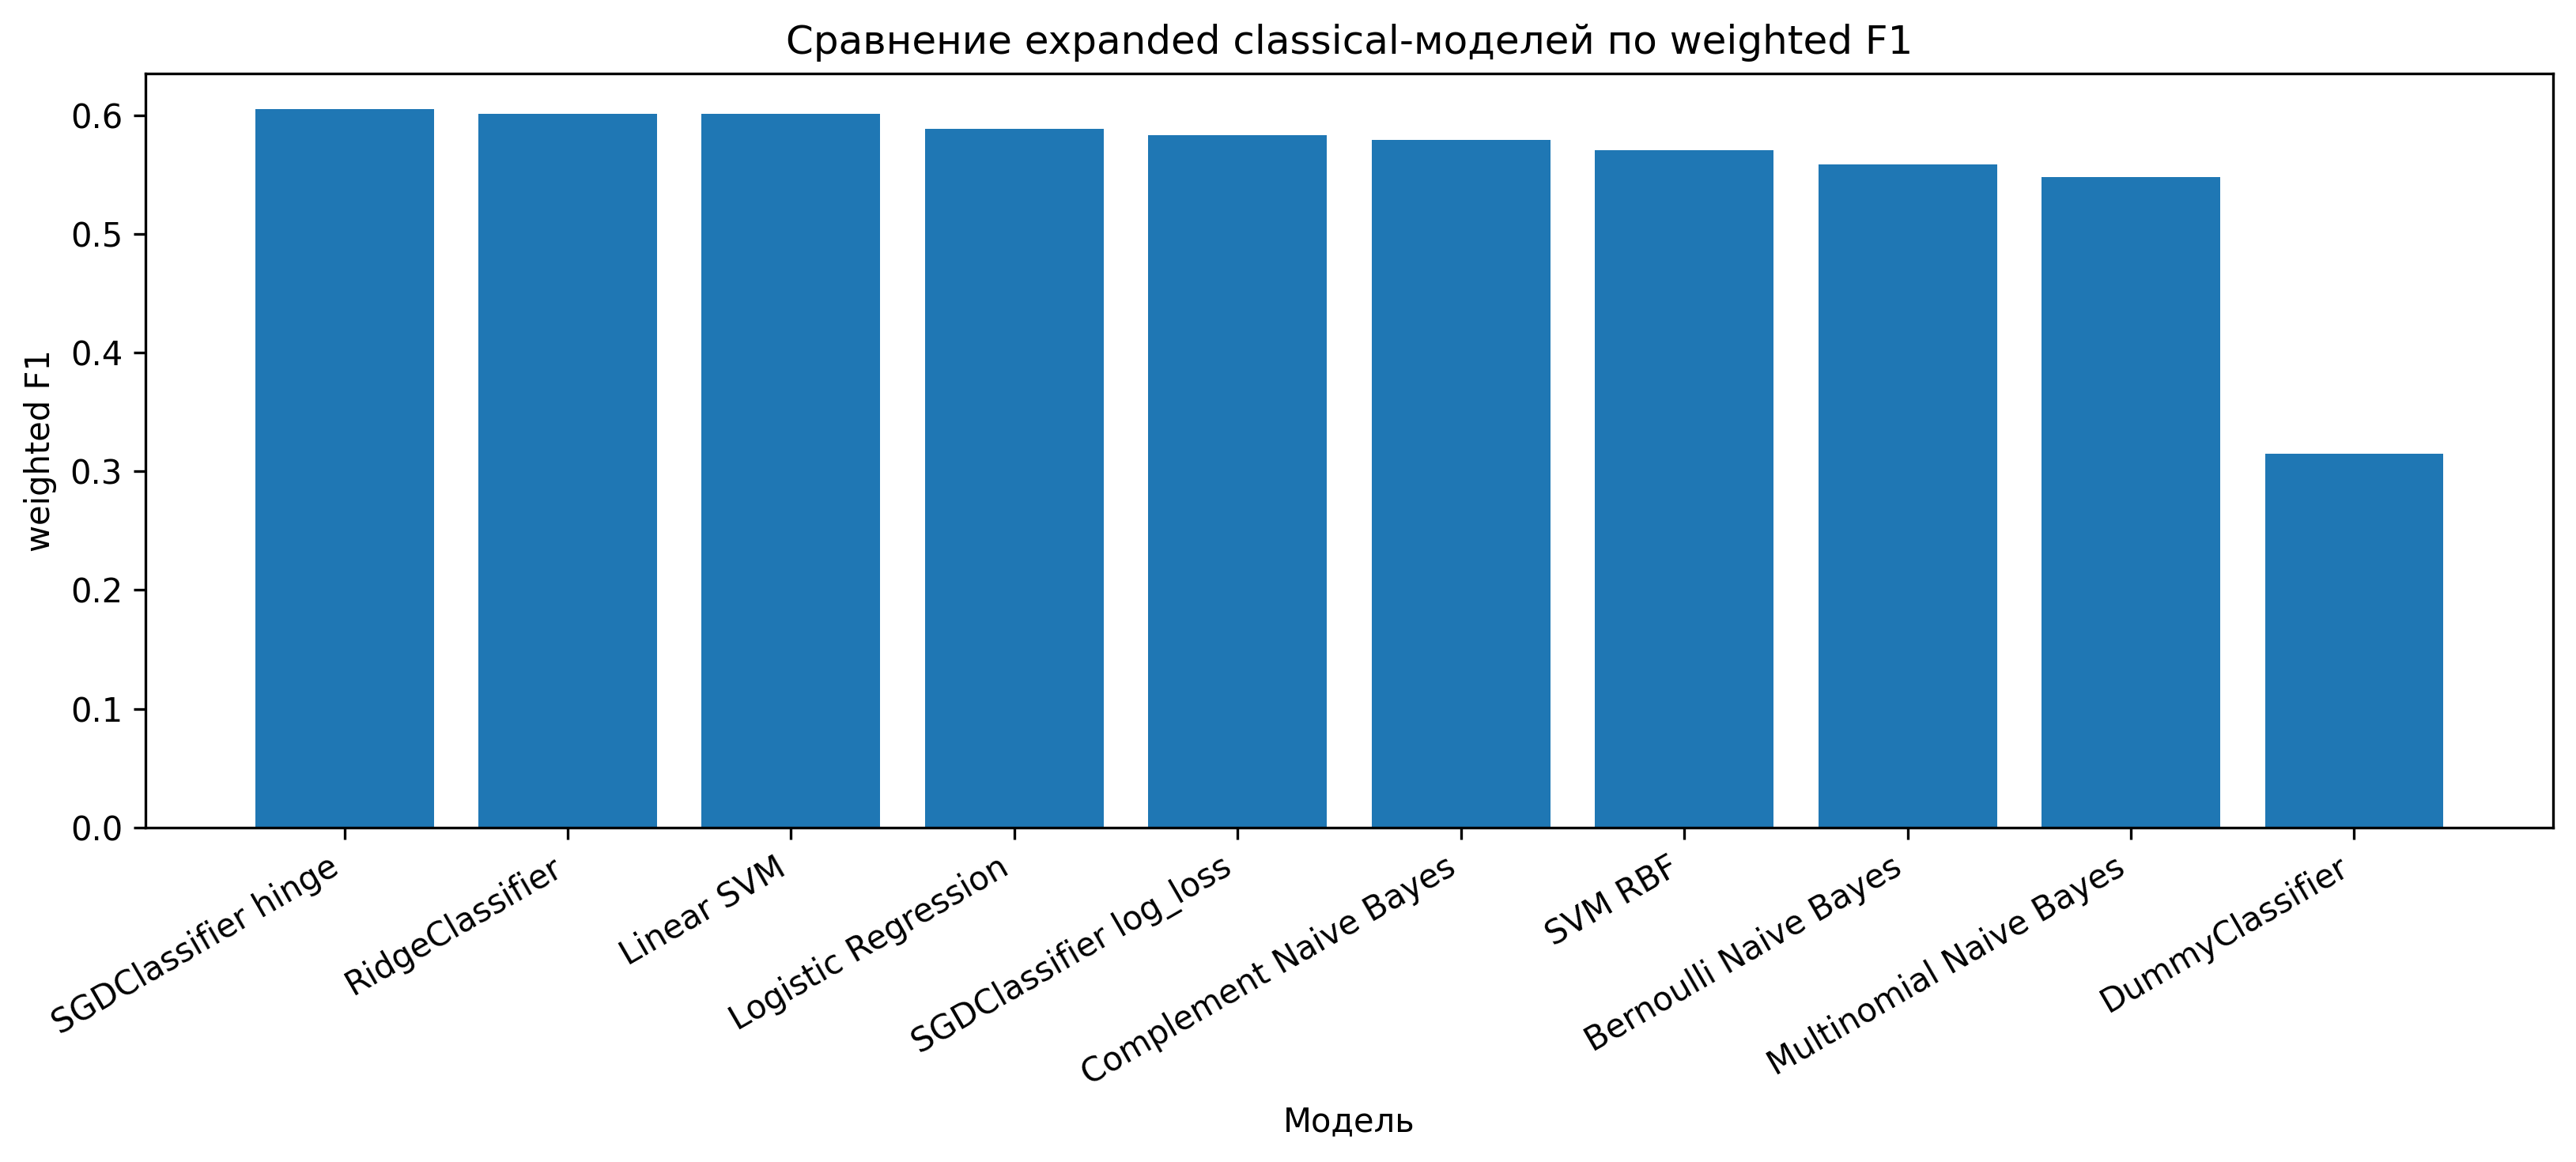

In [22]:
import matplotlib.pyplot as plt

plot_df = e1_results_df.sort_values(by="weighted_f1", ascending=False)

plt.figure(figsize=(11, 5), dpi=300)
plt.bar(plot_df["model"], plot_df["weighted_f1"])
plt.title("Сравнение expanded classical-моделей по weighted F1")
plt.xlabel("Модель")
plt.ylabel("weighted F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e1_models_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

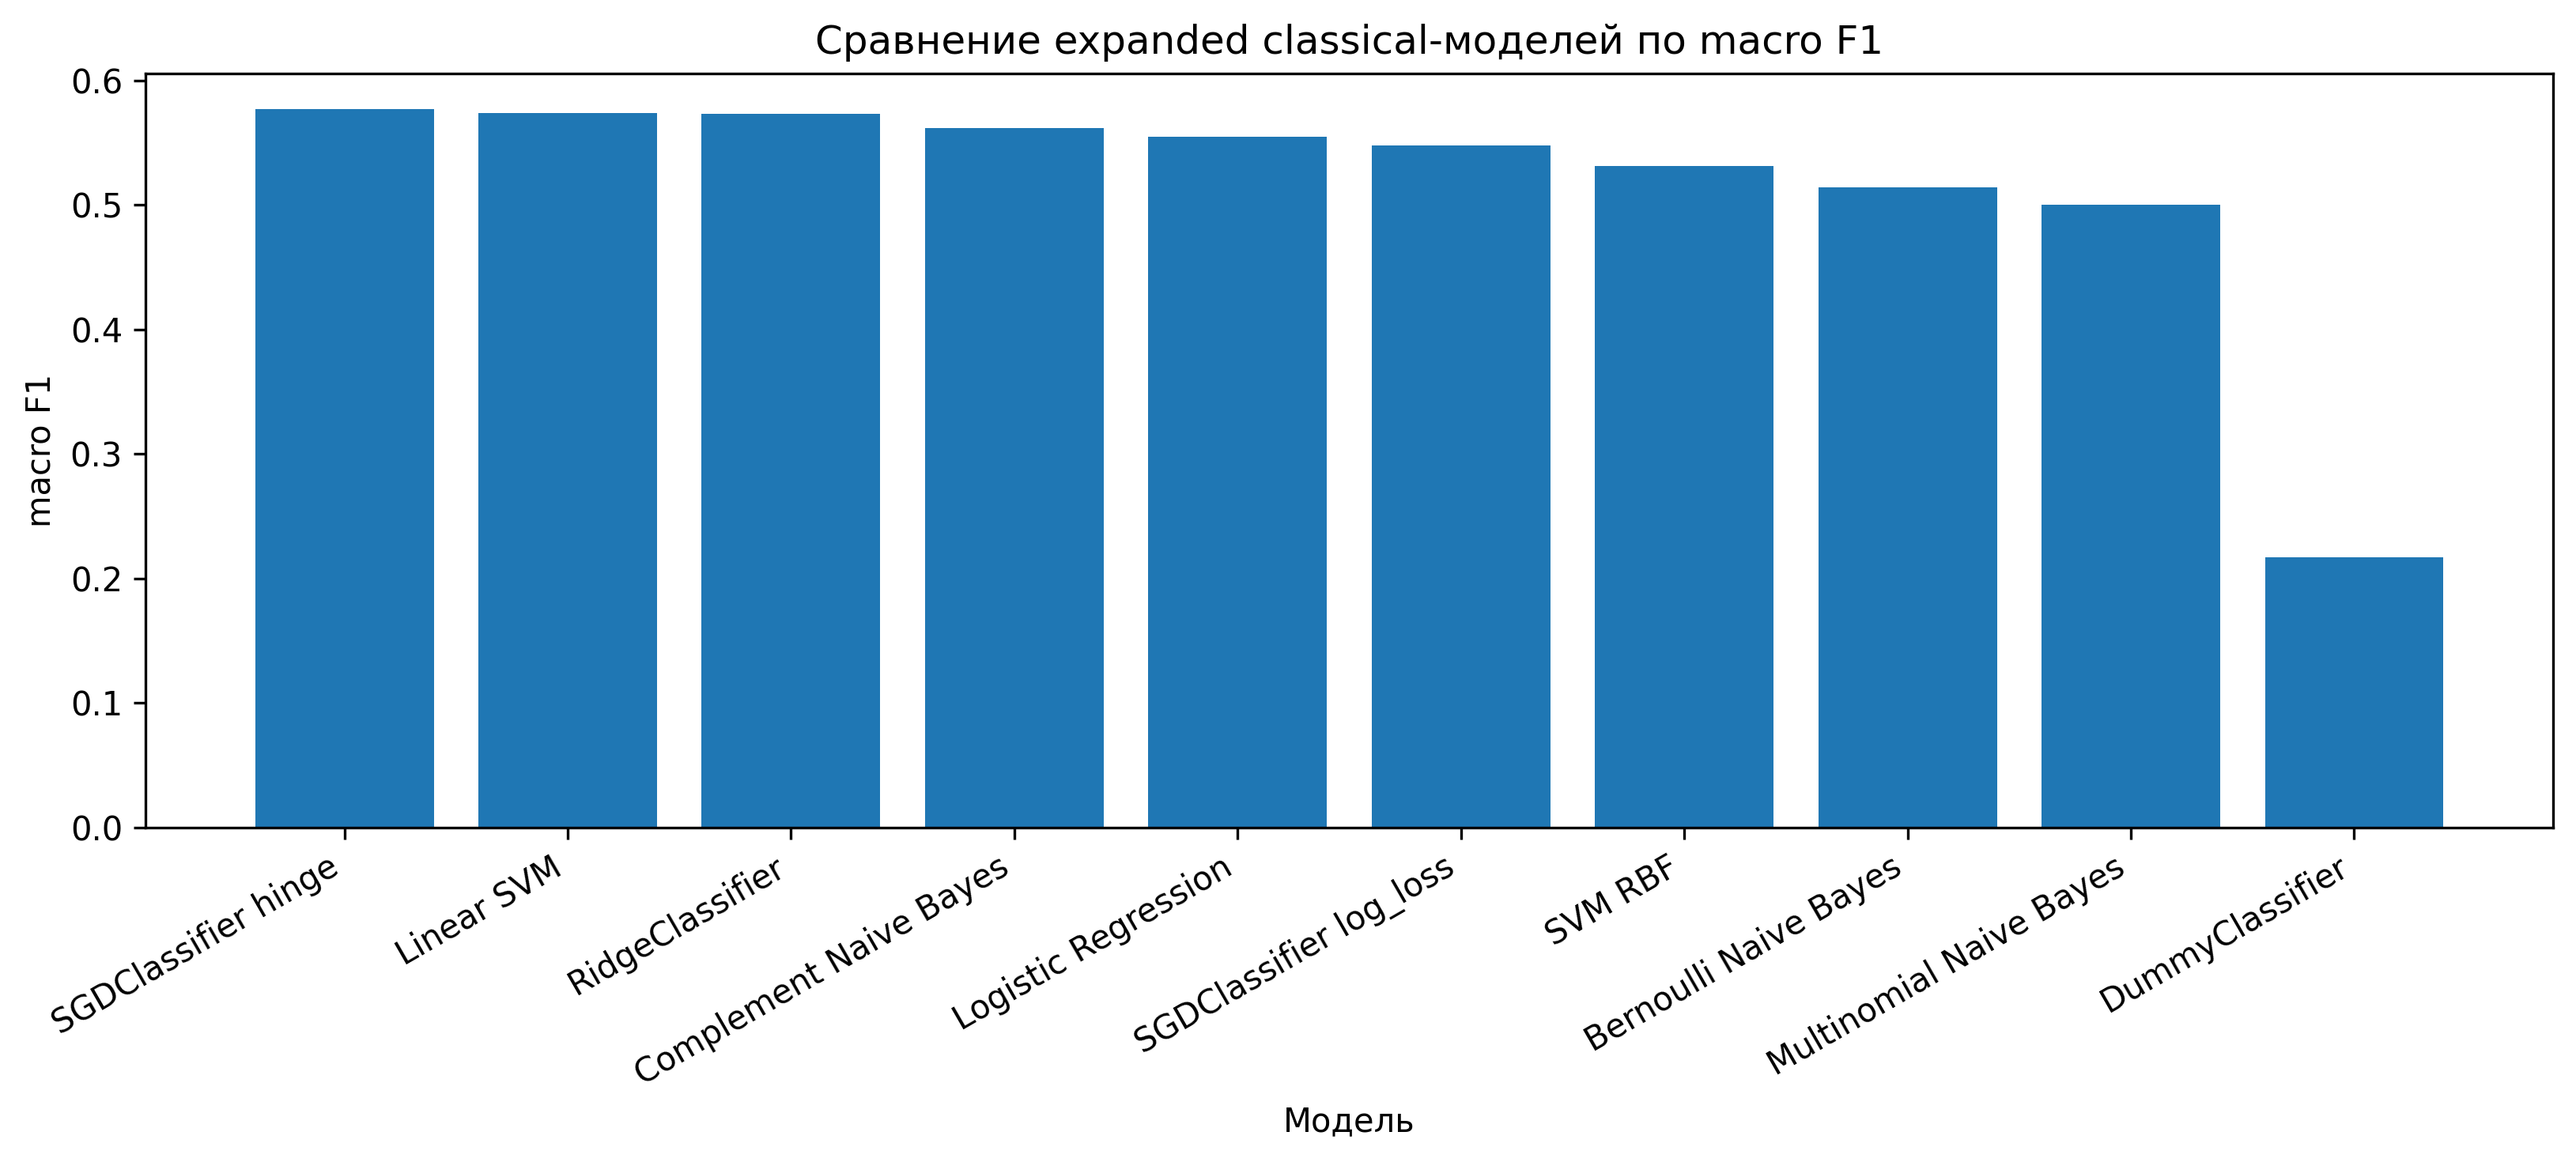

In [23]:
plot_df_macro = e1_results_df.sort_values(by="macro_f1", ascending=False)

plt.figure(figsize=(11, 5), dpi=300)
plt.bar(plot_df_macro["model"], plot_df_macro["macro_f1"])
plt.title("Сравнение expanded classical-моделей по macro F1")
plt.xlabel("Модель")
plt.ylabel("macro F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e1_models_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
best_e1_model_name = e1_results_df.iloc[0]["model"]
print("Best E1 classical model:", best_e1_model_name)

Best E1 classical model: SGDClassifier hinge


In [25]:
predictions_map = {
    "DummyClassifier": y_pred_dummy,
    "Multinomial Naive Bayes": y_pred_mnb,
    "Bernoulli Naive Bayes": y_pred_bnb,
    "Complement Naive Bayes": y_pred_cnb,
    "Logistic Regression": y_pred_logreg,
    "Linear SVM": y_pred_svm,
    "RidgeClassifier": y_pred_ridge,
    "SGDClassifier hinge": y_pred_sgd_hinge,
    "SGDClassifier log_loss": y_pred_sgd_log,
    "SVM RBF": y_pred_rbf_svm
}

best_e1_pred = predictions_map[best_e1_model_name]
print("Predictions selected for:", best_e1_model_name)

Predictions selected for: SGDClassifier hinge


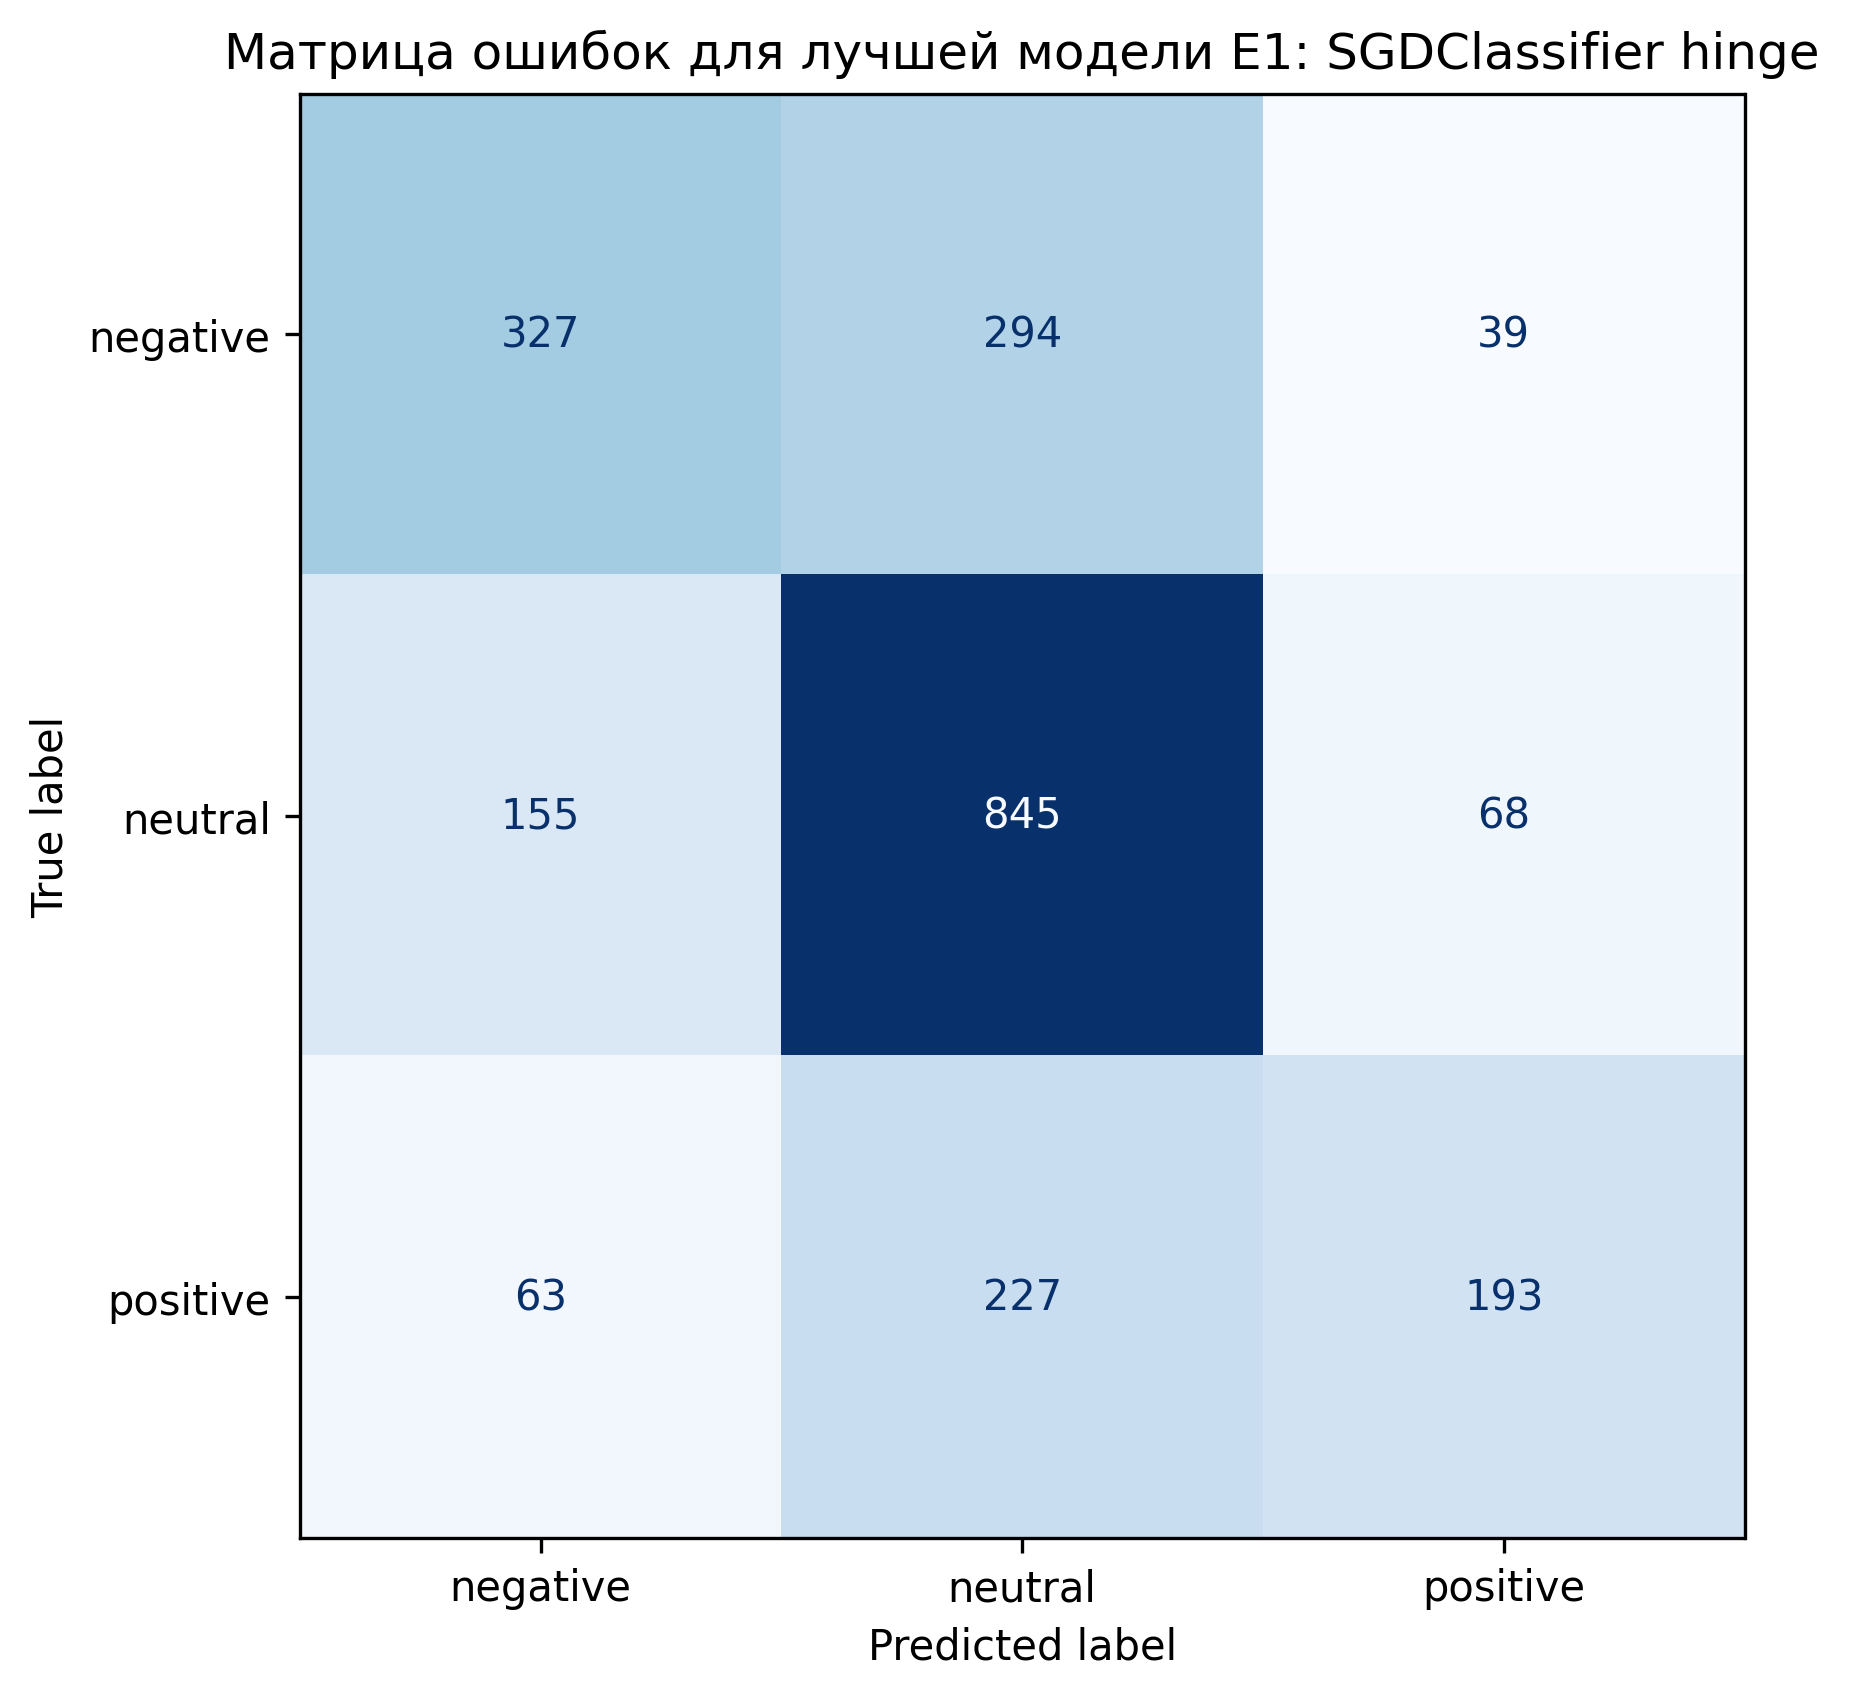

In [26]:
labels_order = ["negative", "neutral", "positive"]

cm_best_e1 = confusion_matrix(y_test, best_e1_pred, labels=labels_order)
disp_best_e1 = ConfusionMatrixDisplay(confusion_matrix=cm_best_e1, display_labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_best_e1.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Матрица ошибок для лучшей модели E1: {best_e1_model_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "e1_best_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
experiment_ids = [f"E1-{i+1}" for i in range(len(e1_results_df))]

e1_registry = e1_results_df.copy()
e1_registry.insert(0, "experiment_id", experiment_ids)
e1_registry["dataset"] = "RuSentiTweet"
e1_registry["train_split"] = "train_final"
e1_registry["test_split"] = "test_final"
e1_registry["status"] = "completed"

display(e1_registry)

,experiment_id,model,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed,dataset,train_split,test_split,status
0,E1-1,SGDClassifier hinge,"TF-IDF word (1,2)",0.6174,0.6184,0.6174,0.6051,0.5767,0.1123,42,RuSentiTweet,train_final,test_final,completed
1,E1-2,RidgeClassifier,"TF-IDF word (1,2)",0.6124,0.6116,0.6124,0.6015,0.5734,0.1277,42,RuSentiTweet,train_final,test_final,completed
2,E1-3,Linear SVM,"TF-IDF word (1,2)",0.6097,0.6057,0.6097,0.6011,0.5737,0.2135,42,RuSentiTweet,train_final,test_final,completed
3,E1-4,Logistic Regression,"TF-IDF word (1,2)",0.6083,0.6183,0.6083,0.5888,0.5546,2.7752,42,RuSentiTweet,train_final,test_final,completed
4,E1-5,SGDClassifier log_loss,"TF-IDF word (1,2)",0.6056,0.6179,0.6056,0.5834,0.5479,0.1186,42,RuSentiTweet,train_final,test_final,completed
5,E1-6,Complement Naive Bayes,"TF-IDF word (1,2)",0.5785,0.5844,0.5785,0.5797,0.5617,0.0434,42,RuSentiTweet,train_final,test_final,completed
6,E1-7,SVM RBF,"TF-IDF word (1,2)",0.6029,0.6326,0.6029,0.5710,0.5310,12.6787,42,RuSentiTweet,train_final,test_final,completed
7,E1-8,Bernoulli Naive Bayes,"Binary Count word (1,2)",0.5957,0.6308,0.5957,0.5590,0.5143,0.0570,42,RuSentiTweet,train_final,test_final,completed
8,E1-9,Multinomial Naive Bayes,"TF-IDF word (1,2)",0.5929,0.6423,0.5929,0.5482,0.4999,0.0312,42,RuSentiTweet,train_final,test_final,completed
9,E1-10,DummyClassifier,"TF-IDF word (1,2)",0.4830,0.2333,0.4830,0.3147,0.2171,0.0140,42,RuSentiTweet,train_final,test_final,completed


In [28]:
e1_registry.to_csv(TABLE_DIR / "e1_experiment_registry.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e1_experiment_registry.csv")

Saved: e1_artifacts/tables/e1_experiment_registry.csv


In [29]:
e1_summary = f"""
E1 CLASSICAL EXPANSION SUMMARY

Goal:
Expand the set of classical baseline models for sentiment classification
on the fixed E0 split.

Dataset:
RuSentiTweet

Train shape:
{train_df.shape}

Test shape:
{test_df.shape}

Best expanded classical model:
{e1_results_df.iloc[0]["model"]}

Best metrics:
accuracy = {e1_results_df.iloc[0]["accuracy"]}
weighted_f1 = {e1_results_df.iloc[0]["weighted_f1"]}
macro_f1 = {e1_results_df.iloc[0]["macro_f1"]}

Full ranking:
{e1_results_df[["model", "representation", "accuracy", "weighted_f1", "macro_f1"]].to_string(index=False)}
"""

with open(LOG_DIR / "e1_summary.txt", "w", encoding="utf-8") as f:
    f.write(e1_summary)

print("Saved:", LOG_DIR / "e1_summary.txt")

Saved: e1_artifacts/logs/e1_summary.txt
